In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
Energy_mean_array = []
Energy_var_array = []
T_array = []

data_step = 50_000
term_step = 5000

In [3]:
min_T = 1.5
max_T = 1.58

T = np.linspace(min_T,max_T,5)

energy = np.loadtxt("./energy_2.csv", delimiter=";")

for i in [1,2,3,4,5]:
    energy_T = energy[(data_step + term_step)*(i-1) + term_step:(data_step + term_step)*i]
    Energy_mean_array.append(np.mean(energy_T))
    Energy_var_array.append(np.var(energy_T))
    T_array.append(T[i-1])

In [4]:
min_T = 1.5
max_T = 1.74

T = np.linspace(min_T,max_T,5)

energy = np.loadtxt("./energy.csv", delimiter=";")

for i in [3,4,5]:
    energy_T = energy[(data_step + term_step)*(i-1) + term_step:(data_step + term_step)*i]
    Energy_mean_array.append(np.mean(energy_T))
    Energy_var_array.append(np.var(energy_T))
    T_array.append(T[i-1])

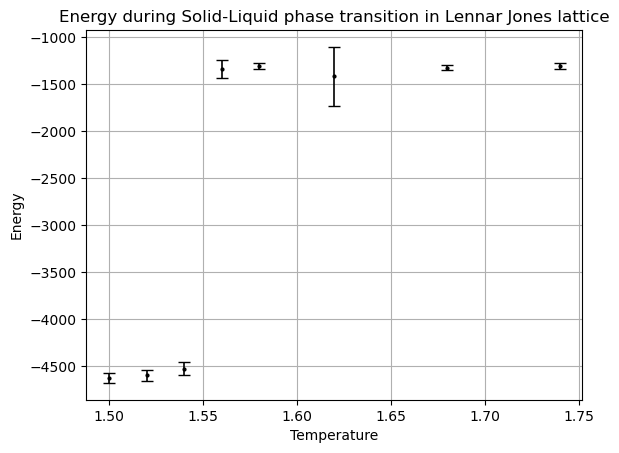

In [ ]:

plt.errorbar(T_array,Energy_mean_array, np.sqrt(Energy_var_array),
            fmt='o',
            markersize=2,
            linestyle='None',
            capsize=4,
            elinewidth=1.2,
            color="k")

plt.xlabel("Temperature")
plt.ylabel("Energy per particle")
plt.title("Energy during Solid-Liquid phase transition in Lennar Jones lattice")
plt.grid()

In [6]:
# ATTENTION CODE GENERATED WITH CHAT GPT JUST TO GET A FAST RESULT AND CHECK SOME STUFF


import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametri
# =========================
file_energy = "output/energy.csv"
delimiter = ";"
thermal_frac = 0.3     # frazione da scartare (30%)
max_lag = None         # None = usa tutta la serie

# =========================
# Caricamento dati
# =========================
energy = np.loadtxt(file_energy, delimiter=delimiter)

# =========================
# Scarto termalizzazione
# =========================
n0 = int(len(energy) * thermal_frac)
energy = energy[n0:]

# =========================
# Fluttuazioni
# =========================
E = energy - np.mean(energy)
N = len(E)

# =========================
# Autocorrelazione (O(N log N))
# =========================
f = np.fft.fft(E, n=2*N)
acf = np.fft.ifft(f * np.conjugate(f)).real[:N]
acf /= acf[0]  # normalizzazione

# =========================
# Taglio lag
# =========================
if max_lag is None:
    max_lag = N // 2

acf = acf[:max_lag]
lags = np.arange(max_lag)

# =========================
# Tempo di autocorrelazione integrato
# τ_int = 1/2 + sum_{t=1}^∞ C(t)
# (taglio al primo valore negativo)
# =========================
neg = np.where(acf < 0)[0]
cut = neg[0] if len(neg) > 0 else max_lag

tau_int = 0.5 + np.sum(acf[1:cut])

print(f"Tempo di autocorrelazione integrato τ_int = {tau_int:.2f} MC steps")
print("Campioni indipendenti ~", N / (2 * tau_int))

# =========================
# Grafico (opzionale)
# =========================
plt.figure(figsize=(6,4))
plt.plot(lags, acf, lw=2)
plt.axvline(cut, color="r", ls="--", label="cut")
plt.xlabel("MC step (lag)")
plt.ylabel("Autocorrelazione")
plt.title("Autocorrelazione dell'energia (Metropolis)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

FileNotFoundError: output/energy.csv not found.

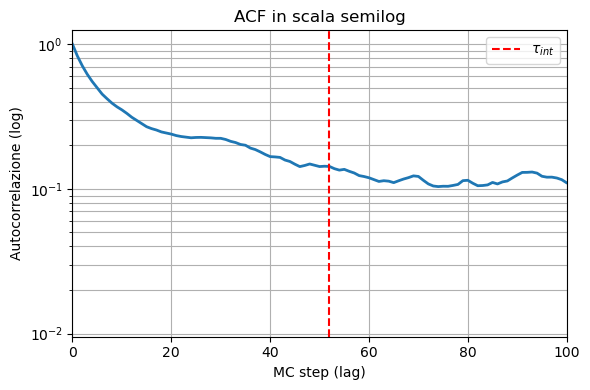

In [ ]:
plt.figure(figsize=(6,4))
plt.semilogy(lags[:500], acf[:500], lw=2)
plt.axvline(tau_int, color="r", ls="--", label=r"$\tau_{int}$")
plt.xlabel("MC step (lag)")
plt.ylabel("Autocorrelazione (log)")
plt.title("ACF in scala semilog")
plt.grid(True, which="both")
plt.legend()
plt.xlim([0,100])
plt.tight_layout()
plt.show()